# 06 — O5 : croisements (préfecture)

Ce notebook **montre** les données de O5. Il ne produit aucun chiffre du 06 : ces chiffres viennent des CSV écrits par `scripts/exploration_06.py` (`data/analysis/06_exploration/`) et des tables du 05 (R-19). Il n'applique aucun seuil du 02, ne classe pas et ne calcule aucun score. Un écart est décrit, pas expliqué ; une date de la chronologie est une coïncidence, pas une cause (H1).

**Ce qu'on regarde** : le réseau (part en mauvais état) face à la formation (auto-écoles comptées pour 100 000 habitants), zone par zone et selon la classe de PA-03, puis les voisines très différentes (contradiction 3). Aucun rang, aucun score, aucun seuil du 02 : la matrice territoires × dimensions (O5-01) vient au 08.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_06 import *
appliquer_style()
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

In [2]:
p = prefectures_geo()
x, y = "Part en mauvais état (%)", "Auto-écoles comptées pour 100 000 habitants"
qx, qy = distribution(x), distribution(y)

## Réseau et formation, zone par zone

Un panneau par zone (plus de trois zones : pas une couleur par zone). En gris, les autres préfectures. Taille : population. Traits : Q1 et Q3 (06 §4). Mô (part non définie) n'apparaît pas.

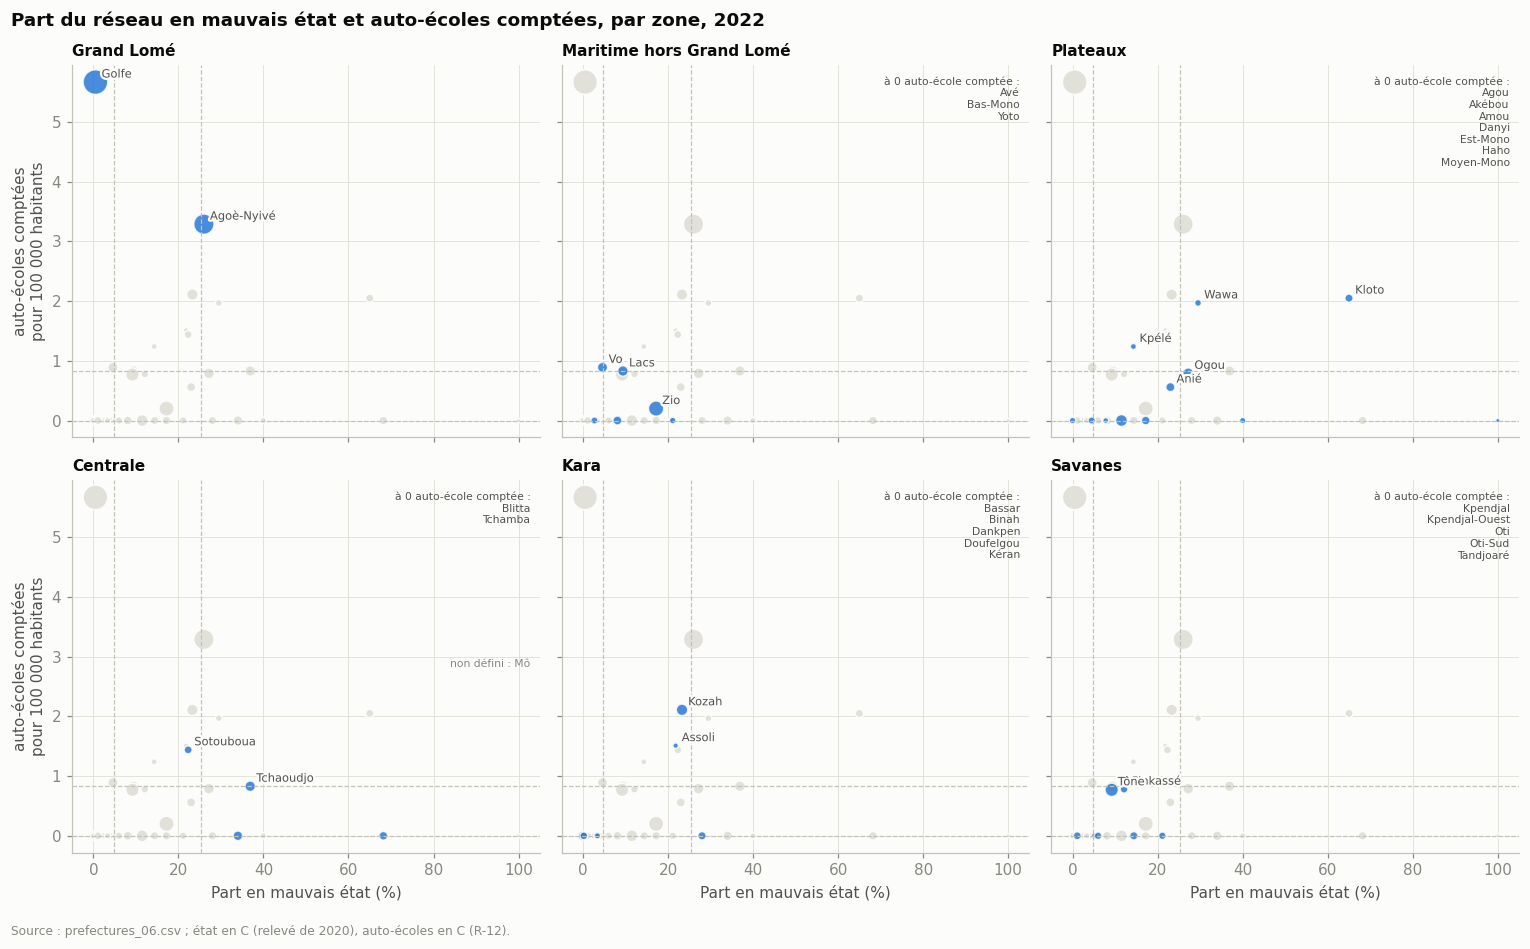

,Zone,Classe PA-03,Population 2022,Part en mauvais état (%),Auto-écoles comptées pour 100 000 habitants
Préfecture,,,,,
Agou,Plateaux,rurale,85793,40.0,0.00
Agoè-Nyivé,Grand Lomé,urbaine,882695,26.0,3.29
Akébou,Plateaux,rurale,73830,7.8,0.00
Amou,Plateaux,rurale,114172,4.5,0.00
Anié,Plateaux,rurale,180158,23.0,0.56
Assoli,Kara,rurale,66394,21.8,1.51
Avé,Maritime hors Grand Lomé,rurale,111214,2.7,0.00
Bas-Mono,Maritime hors Grand Lomé,rurale,94860,21.1,0.00
Bassar,Kara,rurale,152065,28.0,0.00


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8.4), sharex=True, sharey=True)
for ax, z in zip(axes.flat, ZONES):
    autres, s = p[p["Zone"] != z], p[p["Zone"] == z]
    ax.scatter(autres[x], autres[y], s=autres["Population 2022"] / 5000, color=GRILLE, edgecolor=SURFACE)
    ax.scatter(s[x], s[y], s=s["Population 2022"] / 5000, color=SERIES[0], alpha=0.85, edgecolor=SURFACE)
    for _, r in s[s[y] > 0].iterrows():
        if pd.notna(r[x]):
            ax.annotate(r["Préfecture"], (r[x], r[y]), xytext=(4, 3), textcoords="offset points", fontsize=7.5, color=ENCRE_2, path_effects=HALO)
    zeros = s.loc[(s[y] == 0) & s[x].notna(), "Préfecture"].tolist()
    if zeros:
        ax.text(0.98, 0.97, "à 0 auto-école comptée :\n" + "\n".join(zeros), transform=ax.transAxes, ha="right", va="top", fontsize=7, color=ENCRE_2)
    if s[x].isna().any():
        ax.text(0.98, 0.5, "non défini : " + ", ".join(s.loc[s[x].isna(), "Préfecture"]), transform=ax.transAxes, ha="right", fontsize=7, color=MUET)
    for q in (qx["Q1"], qx["Q3"]):
        ax.axvline(q, color=AXE, linestyle="--", linewidth=0.8)
    for q in (qy["Q1"], qy["Q3"]):
        ax.axhline(q, color=AXE, linestyle="--", linewidth=0.8)
    ax.set_title(z, fontsize=10)
for ax in axes[1]:
    ax.set_xlabel(x)
for ax in axes[:, 0]:
    ax.set_ylabel("auto-écoles comptées\npour 100 000 habitants")
fig.suptitle("Part du réseau en mauvais état et auto-écoles comptées, par zone, 2022", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
pied(fig, "Source : prefectures_06.csv ; état en C (relevé de 2020), auto-écoles en C (R-12).")
plt.show()
display(p[["Préfecture", "Zone", "Classe PA-03", "Population 2022", x, y]].set_index("Préfecture"))

## Urbaines et rurales (PA-03)

Grand Lomé urbain par règle ; ailleurs, urbaine si plus de 50 % de la population vit en milieu urbain (RGPH-5).

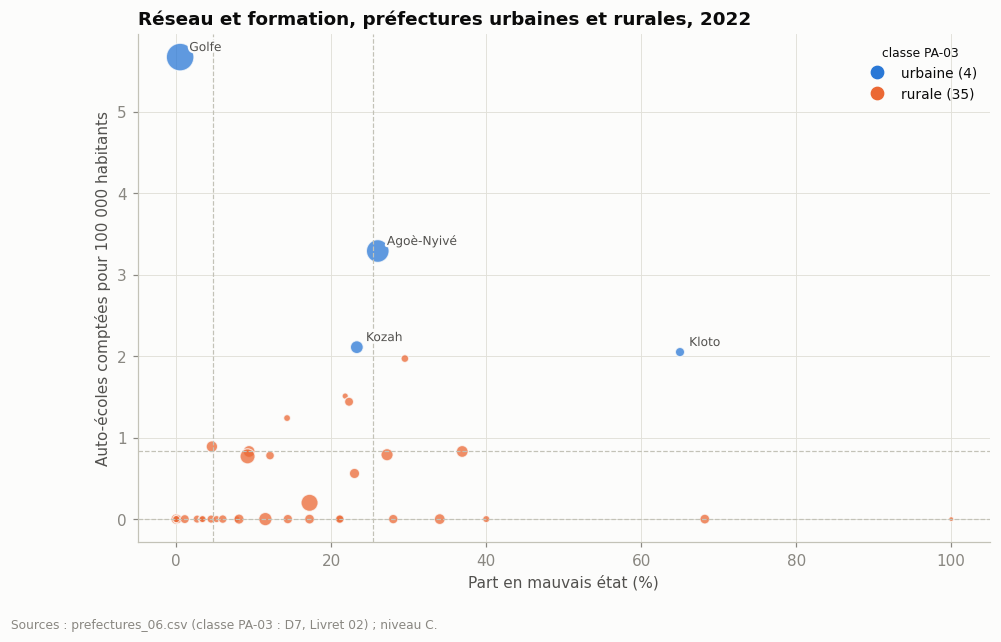

,Préfectures,Population
Classe PA-03,,
rurale,35,5477398
urbaine,4,2618100


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for couleur, cl in zip(SERIES, ["urbaine", "rurale"]):
    s = p[p["Classe PA-03"] == cl]
    ax.scatter(s[x], s[y], s=s["Population 2022"] / 4000, color=couleur, alpha=0.75, edgecolor=SURFACE, linewidth=0.8, label=f"{cl} ({len(s)})")
    if cl == "urbaine":
        for _, r in s.iterrows():
            ax.annotate(r["Préfecture"], (r[x], r[y]), xytext=(6, 4), textcoords="offset points", fontsize=8, color=ENCRE_2, path_effects=HALO)
for q in (qx["Q1"], qx["Q3"]):
    ax.axvline(q, color=AXE, linestyle="--", linewidth=0.8)
for q in (qy["Q1"], qy["Q3"]):
    ax.axhline(q, color=AXE, linestyle="--", linewidth=0.8)
from matplotlib.lines import Line2D
ax.set_xlabel(x); ax.set_ylabel(y)
ax.legend(handles=[Line2D([], [], marker="o", linestyle="none", color=c, markersize=8, label=f"{cl} ({int((p['Classe PA-03'] == cl).sum())})") for c, cl in zip(SERIES, ["urbaine", "rurale"])],
          fontsize=9, title="classe PA-03", title_fontsize=8)
ax.set_title("Réseau et formation, préfectures urbaines et rurales, 2022")
pied(fig, "Sources : prefectures_06.csv (classe PA-03 : D7, Livret 02) ; niveau C.")
plt.show()
display(p.groupby("Classe PA-03").agg(Préfectures=("Préfecture", "count"), Population=("Population 2022", "sum")))

## Voisines très différentes (contradiction 3)

Préfectures voisines : frontière commune (06 §4). Trait : une paire où l'une est dans le quart haut, l'autre dans le quart bas.

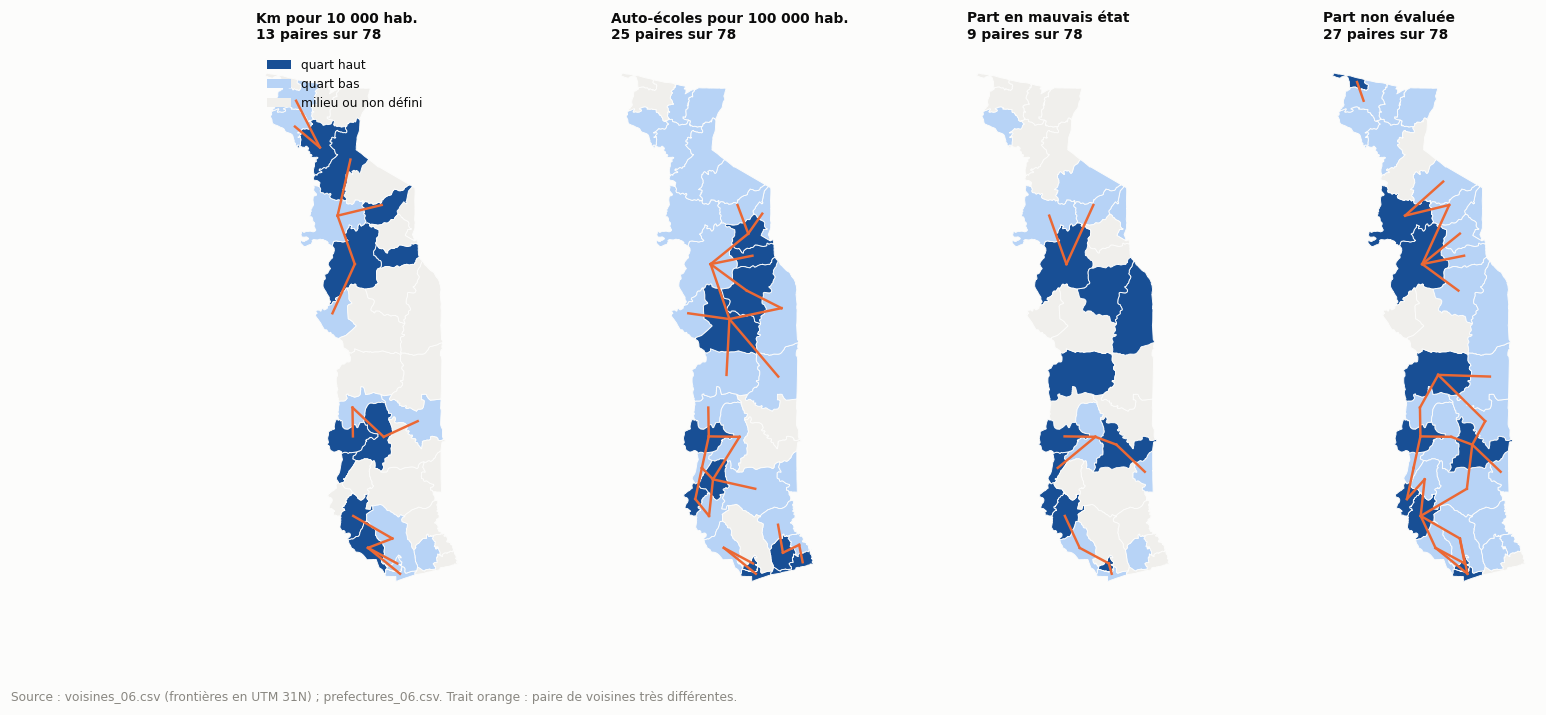

In [5]:
v = exploration("voisines")
centres = p.set_index("Préfecture").geometry.representative_point()
variables = ["Km pour 10 000 habitants", "Auto-écoles comptées pour 100 000 habitants", "Part en mauvais état (%)", "Part non évaluée (%)"]
fig, axes = plt.subplots(1, 4, figsize=(16, 6.6))
for ax, var in zip(axes, variables):
    d = distribution(var)
    pos = p.assign(_classe=[classe(val, d) for val in p[var]])["_classe"]
    couleurs = pos.map({CLASSES[0]: SEQUENTIEL[0], CLASSES[3]: SEQUENTIEL[3]}).fillna("#f0efec")
    p.plot(ax=ax, color=couleurs, edgecolor=SURFACE, linewidth=0.6)
    s = v[(v["Variable"] == var) & v["Très différentes"]]
    for a, b in zip(s["Préfecture A"], s["Préfecture B"]):
        ax.plot([centres[a].x, centres[b].x], [centres[a].y, centres[b].y], color=SERIES[1], linewidth=1.6)
    nettoyer(ax); ax.set_aspect("equal")
    court = {"Km pour 10 000 habitants": "Km pour 10 000 hab.", "Auto-écoles comptées pour 100 000 habitants": "Auto-écoles pour 100 000 hab.",
             "Part en mauvais état (%)": "Part en mauvais état", "Part non évaluée (%)": "Part non évaluée"}[var]
    ax.set_title(f"{court}\n{len(s)} paires sur {int((v['Variable'] == var).sum())}", fontsize=9)
axes[0].legend(handles=[Patch(facecolor=SEQUENTIEL[3], label="quart haut"), Patch(facecolor=SEQUENTIEL[0], label="quart bas"),
                        Patch(facecolor="#f0efec", label="milieu ou non défini")], fontsize=8, loc="upper left")
pied(fig, "Source : voisines_06.csv (frontières en UTM 31N) ; prefectures_06.csv. Trait orange : paire de voisines très différentes.")
plt.show()

## Les cinq contradictions (`signaux_06.csv`)

Chaque contradiction a sa ligne, trouvée ou non.

In [6]:
display(signaux("Contradiction"))

,Résumé,Niveau,Question transmise
ID,,,
SIG-31,Contradiction 1 (formation) : 1 préfecture(s) à population haute et auto-écoles comptées pour 100 000 habitants bas : Haho (305 096 habi...,C,"Ces préfectures, peuplées et peu dotées : leur population est la population concernée (O5-03), à afficher à côté du taux."
SIG-32,"Contradiction 1 (réseau) : 5 préfecture(s) à population haute et km pour 10 000 habitants bas : Agoè-Nyivé, Golfe, Tône, Vo, Zio (3 301 ...",B,"Ces préfectures, peuplées et peu dotées : leur population est la population concernée (O5-03), à afficher à côté du taux."
SIG-33,"Contradiction 2a : 9 préfecture(s) au réseau hors du quart bas et à part en mauvais état haute : Agou, Bassar, Blitta, Danyi, Kloto, Ogo...",C,Ici le réseau existe mais il est dégradé : le 07 lit-il ces préfectures sur l’état (O3-02) plutôt que sur la quantité (O4-03) ?
SIG-34,Contradiction 2b : 0 préfecture(s) avec au moins une auto-école comptée mais un point de départ loin de la plus proche : aucune,C,"La distance montre-t-elle un manque que le nombre ne montre pas ? Le 07 affiche les deux (O4-05, O4-08)."
SIG-35,"Contradiction 2c : 2 zone(s) où plus de ménages possèdent une moto que la médiane des 6 zones, avec moins d’auto-écoles comptées pour 10...",C,"L’usage déclaré (EHCVM, C) va-t-il contre l’offre de formation ? Lecture par zone seulement."
SIG-36,"Contradiction 3 (km pour 10 000 habitants) : 13 paire(s) de voisines, l’une dans le quart haut, l’autre dans le quart bas, sur 78 paires...",B,"Ces écarts entre voisines tiennent-ils à la donnée (limite, rattachement) ou au territoire ? À vérifier avant de les afficher."
SIG-37,"Contradiction 3 (auto-écoles comptées pour 100 000 habitants) : 25 paire(s) de voisines, l’une dans le quart haut, l’autre dans le quart...",C,"Ces écarts entre voisines tiennent-ils à la donnée (limite, rattachement) ou au territoire ? À vérifier avant de les afficher."
SIG-38,"Contradiction 3 (part en mauvais état (%)) : 9 paire(s) de voisines, l’une dans le quart haut, l’autre dans le quart bas, sur 78 paires ...",C,"Ces écarts entre voisines tiennent-ils à la donnée (limite, rattachement) ou au territoire ? À vérifier avant de les afficher."
SIG-39,"Contradiction 3 (part non évaluée (%)) : 27 paire(s) de voisines, l’une dans le quart haut, l’autre dans le quart bas, sur 78 paires : A...",B,"Ces écarts entre voisines tiennent-ils à la donnée (limite, rattachement) ou au territoire ? À vérifier avant de les afficher."
